In [1]:
import json
import numpy as np

EMBED_FILE = "../data/embeddings/ministry_embeddings1.json"

def load_embeddings():
    with open(EMBED_FILE, "r") as f:
        data = json.load(f)

    for k in data:
        data[k] = np.array(data[k])

    return data

ministry_embeddings = load_embeddings()

# convert to matrix
names = list(ministry_embeddings.keys())
X = np.vstack([ministry_embeddings[k] for k in names])

print(X.shape)  # (53, 384)

(53, 384)


In [2]:
from sklearn.cluster import KMeans

def kmeans_clustering(X, k=8):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    return labels

labels_kmeans = kmeans_clustering(X, k=10)

In [3]:
from sklearn.mixture import GaussianMixture

def gmm_clustering(X, k=10):
    model = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    labels = model.fit_predict(X)
    return labels

labels_gmm = gmm_clustering(X, k=10)

In [4]:
from sklearn.cluster import AgglomerativeClustering

def hierarchical_clustering(X, k=10):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X)
    return labels

labels_hier = hierarchical_clustering(X, k=10)

In [5]:
from sklearn.cluster import DBSCAN

def dbscan_clustering(X, eps=0.5, min_samples=3):
    model = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine')
    labels = model.fit_predict(X)
    return labels

labels_dbscan = dbscan_clustering(X)

In [6]:
from sklearn.cluster import SpectralClustering

def spectral_clustering(X, k=10):
    model = SpectralClustering(
        n_clusters=k,
        affinity='cosine',
        random_state=42
    )
    labels = model.fit_predict(X)
    return labels

labels_spectral = spectral_clustering(X, k=10)

In [7]:
from sklearn.neighbors import kneighbors_graph
import networkx as nx

def knn_graph_clustering(X, k=10):
    A = kneighbors_graph(X, k, mode='connectivity', include_self=False)
    G = nx.from_scipy_sparse_array(A)

    # community detection
    communities = nx.algorithms.community.greedy_modularity_communities(G)

    labels = np.zeros(len(X))
    for i, comm in enumerate(communities):
        for node in comm:
            labels[node] = i

    return labels

labels_knn = knn_graph_clustering(X, k=10)

In [8]:
from sklearn.metrics import silhouette_score

def evaluate(X, labels):
    # ignore cases like DBSCAN where only 1 cluster
    if len(set(labels)) > 1:
        return silhouette_score(X, labels)
    return -1

print("KMeans:", evaluate(X, labels_kmeans))
print("GMM:", evaluate(X, labels_gmm))
print("Hierarchical:", evaluate(X, labels_hier))
print("Spectral:", evaluate(X, labels_spectral))
print("DBSCAN:", evaluate(X, labels_dbscan))
print("KNN Graph:", evaluate(X, labels_knn))

KMeans: 0.06186388039341198
GMM: 0.03779011630093617
Hierarchical: 0.0818013464871581
Spectral: 0.05415678581282972
DBSCAN: -1
KNN Graph: 0.046281402444068434


In [9]:
def print_clusters(names, labels):
    clusters = {}
    for name, label in zip(names, labels):
        clusters.setdefault(label, []).append(name)

    for k, v in clusters.items():
        print(f"\nCluster {k}:")
        for m in v:
            print("  ", m)

print_clusters(names, labels_kmeans)


Cluster 6:
   Ministry_of_AYUSH_MoA_
   Ministry_of_Health_and_Family_Welfare_MoHFW_

Cluster 1:
   Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_
   Ministry_of_Chemicals_and_Fertilizers_MoCF_
   Ministry_of_Consumer_Affairs_Food_and_Public_Distribution_MoCAF_PD_
   Ministry_of_Cooperation_MoC_
   Ministry_of_Development_of_North_Eastern_Region_MDoNER_
   Ministry_of_Education_MoE_
   Ministry_of_Fisheries_Animal_Husbandry_and_Dairying_MoFAHD_
   Ministry_of_Food_Processing_Industries_MoFPI_
   Ministry_of_Jal_Shakti_MoJS_
   Ministry_of_Planning_MoP_

Cluster 0:
   Ministry_of_Civil_Aviation_MoCA_
   Ministry_of_Communications_MoC_
   Ministry_of_Electronics_and_Information_Technology_MeitY_
   Ministry_of_Information_and_Broadcasting_MIB_

Cluster 9:
   Ministry_of_Coal_MoC_
   Ministry_of_Mines_MoM_
   Ministry_of_Petroleum_and_Natural_Gas_MoPNG_

Cluster 2:
   Ministry_of_Commerce_and_Industry_MoCI_
   Ministry_of_Corporate_Affairs_MCA_
   Ministry_of_External_Affairs_MEA_
  

In [10]:
print_clusters(names, labels_kmeans)


Cluster 6:
   Ministry_of_AYUSH_MoA_
   Ministry_of_Health_and_Family_Welfare_MoHFW_

Cluster 1:
   Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_
   Ministry_of_Chemicals_and_Fertilizers_MoCF_
   Ministry_of_Consumer_Affairs_Food_and_Public_Distribution_MoCAF_PD_
   Ministry_of_Cooperation_MoC_
   Ministry_of_Development_of_North_Eastern_Region_MDoNER_
   Ministry_of_Education_MoE_
   Ministry_of_Fisheries_Animal_Husbandry_and_Dairying_MoFAHD_
   Ministry_of_Food_Processing_Industries_MoFPI_
   Ministry_of_Jal_Shakti_MoJS_
   Ministry_of_Planning_MoP_

Cluster 0:
   Ministry_of_Civil_Aviation_MoCA_
   Ministry_of_Communications_MoC_
   Ministry_of_Electronics_and_Information_Technology_MeitY_
   Ministry_of_Information_and_Broadcasting_MIB_

Cluster 9:
   Ministry_of_Coal_MoC_
   Ministry_of_Mines_MoM_
   Ministry_of_Petroleum_and_Natural_Gas_MoPNG_

Cluster 2:
   Ministry_of_Commerce_and_Industry_MoCI_
   Ministry_of_Corporate_Affairs_MCA_
   Ministry_of_External_Affairs_MEA_
  

In [11]:

print_clusters(names, labels_gmm)


Cluster 6:
   Ministry_of_AYUSH_MoA_
   Ministry_of_Chemicals_and_Fertilizers_MoCF_
   Ministry_of_Health_and_Family_Welfare_MoHFW_

Cluster 0:
   Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_
   Ministry_of_Fisheries_Animal_Husbandry_and_Dairying_MoFAHD_

Cluster 8:
   Ministry_of_Civil_Aviation_MoCA_
   Ministry_of_Commerce_and_Industry_MoCI_
   Ministry_of_Corporate_Affairs_MCA_
   Ministry_of_External_Affairs_MEA_
   Ministry_of_Law_and_Justice_MoLJ_

Cluster 3:
   Ministry_of_Coal_MoC_
   Ministry_of_Culture
   Ministry_of_Defence_MoD_
   Ministry_of_Finance_MoF_
   Ministry_of_Mines_MoM_
   Ministry_of_Parliamentary_Affairs_MPA_
   Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_
   Ministry_of_Petroleum_and_Natural_Gas_MoPNG_
   Ministry_of_Planning_MoP_
   Ministry_of_Tourism_MoT_

Cluster 4:
   Ministry_of_Communications_MoC_
   Ministry_of_Electronics_and_Information_Technology_MeitY_
   Ministry_of_Information_and_Broadcasting_MIB_
   Ministry_of_Ports_Ship

In [12]:

print_clusters(names, labels_hier)


Cluster 6:
   Ministry_of_AYUSH_MoA_
   Ministry_of_Health_and_Family_Welfare_MoHFW_

Cluster 4:
   Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_
   Ministry_of_Chemicals_and_Fertilizers_MoCF_
   Ministry_of_Consumer_Affairs_Food_and_Public_Distribution_MoCAF_PD_
   Ministry_of_Cooperation_MoC_
   Ministry_of_Fisheries_Animal_Husbandry_and_Dairying_MoFAHD_
   Ministry_of_Food_Processing_Industries_MoFPI_

Cluster 1:
   Ministry_of_Civil_Aviation_MoCA_
   Ministry_of_Ports_Shipping_and_Waterways_MoPSW_
   Ministry_of_Railways_MoR_
   Ministry_of_Road_Transport_and_Highways_MoRTH_

Cluster 0:
   Ministry_of_Coal_MoC_
   Ministry_of_Heavy_Industries_MoHI_
   Ministry_of_Micro_Small_Medium_Enterprises_MoME_
   Ministry_of_Mines_MoM_
   Ministry_of_New_and_Renewable_Energy_MNRE_
   Ministry_of_Petroleum_and_Natural_Gas_MoPNG_
   Ministry_of_Power_MoP_
   Ministry_of_Steel_MoS_
   Ministry_of_Textiles_MoT_

Cluster 5:
   Ministry_of_Commerce_and_Industry_MoCI_
   Ministry_of_Corporate_

In [13]:

print_clusters(names, labels_spectral)


Cluster 7:
   Ministry_of_AYUSH_MoA_
   Ministry_of_Earth_Sciences_MoES_
   Ministry_of_Health_and_Family_Welfare_MoHFW_
   Ministry_of_Science_and_Technology_MST_
   Ministry_of_Youth_Affairs_and_Sports_MoYAS_

Cluster 1:
   Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_
   Ministry_of_Chemicals_and_Fertilizers_MoCF_
   Ministry_of_Consumer_Affairs_Food_and_Public_Distribution_MoCAF_PD_
   Ministry_of_Fisheries_Animal_Husbandry_and_Dairying_MoFAHD_
   Ministry_of_Food_Processing_Industries_MoFPI_
   Ministry_of_Micro_Small_Medium_Enterprises_MoME_

Cluster 4:
   Ministry_of_Civil_Aviation_MoCA_
   Ministry_of_Communications_MoC_
   Ministry_of_Electronics_and_Information_Technology_MeitY_
   Ministry_of_Information_and_Broadcasting_MIB_

Cluster 6:
   Ministry_of_Coal_MoC_
   Ministry_of_Mines_MoM_
   Ministry_of_Petroleum_and_Natural_Gas_MoPNG_
   Ministry_of_Steel_MoS_

Cluster 8:
   Ministry_of_Commerce_and_Industry_MoCI_
   Ministry_of_Development_of_North_Eastern_Region_MDoN

In [14]:

print_clusters(names, labels_dbscan)


Cluster 0:
   Ministry_of_AYUSH_MoA_
   Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_
   Ministry_of_Chemicals_and_Fertilizers_MoCF_
   Ministry_of_Civil_Aviation_MoCA_
   Ministry_of_Coal_MoC_
   Ministry_of_Commerce_and_Industry_MoCI_
   Ministry_of_Communications_MoC_
   Ministry_of_Consumer_Affairs_Food_and_Public_Distribution_MoCAF_PD_
   Ministry_of_Cooperation_MoC_
   Ministry_of_Corporate_Affairs_MCA_
   Ministry_of_Culture
   Ministry_of_Defence_MoD_
   Ministry_of_Development_of_North_Eastern_Region_MDoNER_
   Ministry_of_Earth_Sciences_MoES_
   Ministry_of_Education_MoE_
   Ministry_of_Electronics_and_Information_Technology_MeitY_
   Ministry_of_Environment_Forest_and_Climate_Change_MoEFCC_
   Ministry_of_External_Affairs_MEA_
   Ministry_of_Finance_MoF_
   Ministry_of_Fisheries_Animal_Husbandry_and_Dairying_MoFAHD_
   Ministry_of_Food_Processing_Industries_MoFPI_
   Ministry_of_Health_and_Family_Welfare_MoHFW_
   Ministry_of_Heavy_Industries_MoHI_
   Ministry_of_Home_

In [15]:

print_clusters(names, labels_knn)


Cluster 1.0:
   Ministry_of_AYUSH_MoA_
   Ministry_of_Cooperation_MoC_
   Ministry_of_Corporate_Affairs_MCA_
   Ministry_of_Culture
   Ministry_of_Defence_MoD_
   Ministry_of_Development_of_North_Eastern_Region_MDoNER_
   Ministry_of_External_Affairs_MEA_
   Ministry_of_Finance_MoF_
   Ministry_of_Health_and_Family_Welfare_MoHFW_
   Ministry_of_Home_Affairs_MHA_
   Ministry_of_Housing_and_Urban_Affairs_MoHUA_
   Ministry_of_Jal_Shakti_MoJS_
   Ministry_of_Labour_and_Employment_MoLE_
   Ministry_of_Law_and_Justice_MoLJ_
   Ministry_of_Minority_Affairs_MoMA_
   Ministry_of_Panchayati_Raj_MoPR_
   Ministry_of_Parliamentary_Affairs_MPA_
   Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_
   Ministry_of_Rural_Development_MoRD_
   Ministry_of_Social_Justice_and_Empowerment_MoSJE_
   Ministry_of_Tribal_Affairs_MoTA_
   Ministry_of_Women_and_Child_Development_MoWCD_

Cluster 0.0:
   Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_
   Ministry_of_Chemicals_and_Fertilizers_MoCF_
 

In [16]:
all_labels = {
    "kmeans": labels_kmeans,
    "gmm": labels_gmm,
    "hier": labels_hier,
    "spectral": labels_spectral,
    "knn": labels_knn,
}

In [17]:
n = len(names)
co_matrix = np.zeros((n, n))

for algo, labels in all_labels.items():
    for i in range(n):
        for j in range(n):
            if labels[i] == labels[j]:
                co_matrix[i][j] += 1

In [18]:
co_matrix = co_matrix / len(all_labels)

In [19]:
threshold = 0.8  # adjust

pairs = []
for i in range(n):
    for j in range(i+1, n):
        if co_matrix[i][j] >= threshold:
            pairs.append((names[i], names[j]))

print("Strong pairs:")
for p in pairs:
    print(p)

Strong pairs:
('Ministry_of_AYUSH_MoA_', 'Ministry_of_Health_and_Family_Welfare_MoHFW_')
('Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_', 'Ministry_of_Chemicals_and_Fertilizers_MoCF_')
('Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_', 'Ministry_of_Consumer_Affairs_Food_and_Public_Distribution_MoCAF_PD_')
('Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_', 'Ministry_of_Fisheries_Animal_Husbandry_and_Dairying_MoFAHD_')
('Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_', 'Ministry_of_Food_Processing_Industries_MoFPI_')
('Ministry_of_Chemicals_and_Fertilizers_MoCF_', 'Ministry_of_Consumer_Affairs_Food_and_Public_Distribution_MoCAF_PD_')
('Ministry_of_Chemicals_and_Fertilizers_MoCF_', 'Ministry_of_Fisheries_Animal_Husbandry_and_Dairying_MoFAHD_')
('Ministry_of_Chemicals_and_Fertilizers_MoCF_', 'Ministry_of_Food_Processing_Industries_MoFPI_')
('Ministry_of_Coal_MoC_', 'Ministry_of_Mines_MoM_')
('Ministry_of_Coal_MoC_', 'Ministry_of_Petroleum_and_Natural_Gas_MoPNG_')
('Minist

In [20]:
# Due to high semantic overlap in ministry embeddings, traditional clustering methods produced weak separation (silhouette < 0.1).
# Therefore, we adopted a consensus-based clustering approach to identify stable ministry groupings.

In [21]:
import networkx as nx

G = nx.Graph()

for i in range(n):
    G.add_node(names[i])

for i in range(n):
    for j in range(i+1, n):
        if co_matrix[i][j] >= 0.8:
            G.add_edge(names[i], names[j])

components = list(nx.connected_components(G))

for i, comp in enumerate(components):
    print(f"\nStable Cluster {i}:")
    for m in comp:
        print(" ", m)


Stable Cluster 0:
  Ministry_of_AYUSH_MoA_
  Ministry_of_Health_and_Family_Welfare_MoHFW_

Stable Cluster 1:
  Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_
  Ministry_of_Food_Processing_Industries_MoFPI_
  Ministry_of_Chemicals_and_Fertilizers_MoCF_
  Ministry_of_Fisheries_Animal_Husbandry_and_Dairying_MoFAHD_
  Ministry_of_Consumer_Affairs_Food_and_Public_Distribution_MoCAF_PD_

Stable Cluster 2:
  Ministry_of_Civil_Aviation_MoCA_

Stable Cluster 3:
  Ministry_of_Mines_MoM_
  Ministry_of_Coal_MoC_
  Ministry_of_Petroleum_and_Natural_Gas_MoPNG_

Stable Cluster 4:
  Ministry_of_Finance_MoF_
  Ministry_of_Law_and_Justice_MoLJ_
  Ministry_of_External_Affairs_MEA_
  Ministry_of_Corporate_Affairs_MCA_
  Ministry_of_Commerce_and_Industry_MoCI_

Stable Cluster 5:
  Ministry_of_Electronics_and_Information_Technology_MeitY_
  Ministry_of_Communications_MoC_
  Ministry_of_Information_and_Broadcasting_MIB_

Stable Cluster 6:
  Ministry_of_Cooperation_MoC_

Stable Cluster 7:
  Ministry_of_T

In [22]:
import umap
import matplotlib.pyplot as plt

def visualize_clusters(X, labels, names, title="Cluster Visualization"):
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_2d = reducer.fit_transform(X)

    plt.figure(figsize=(10, 7))
    
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels)
    
    # annotate points (optional but useful for your case)
    for i, name in enumerate(names):
        plt.text(X_2d[i, 0], X_2d[i, 1], name, fontsize=7)

    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.show()

/home/devadatta/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


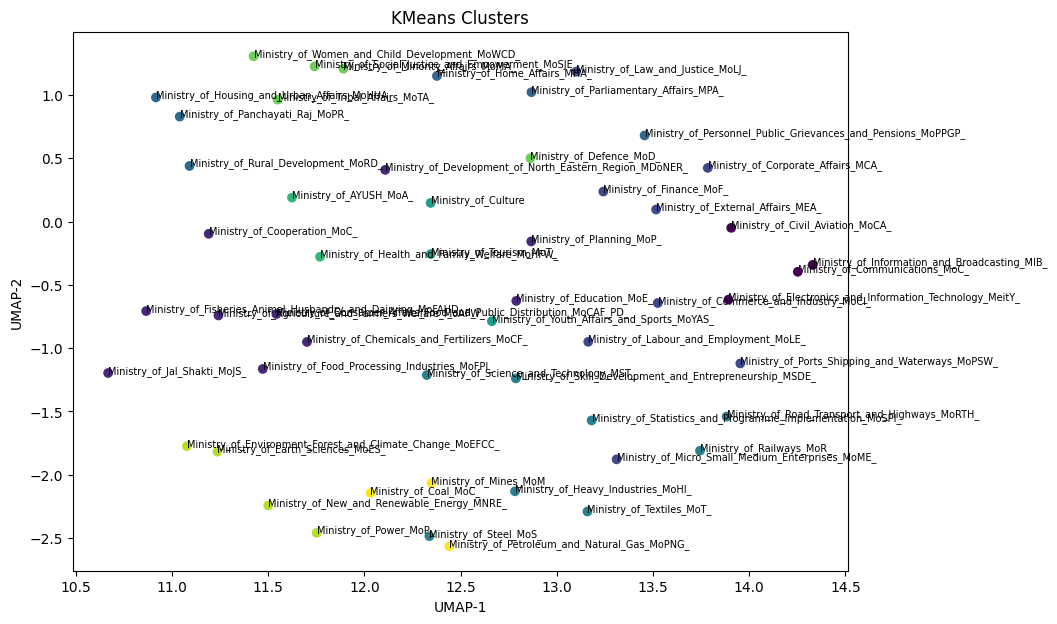

/home/devadatta/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


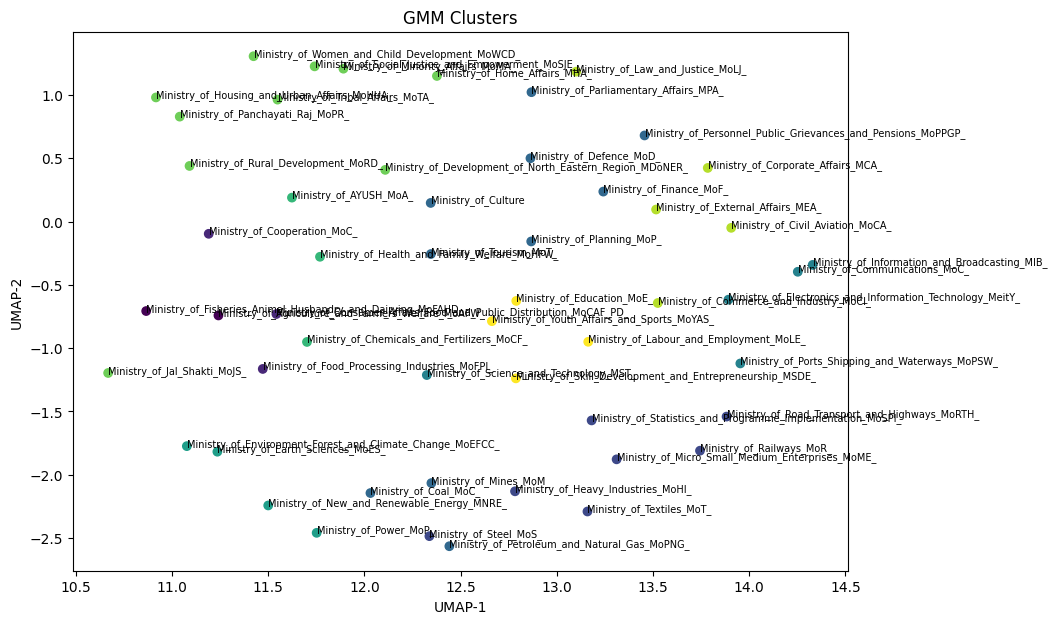

/home/devadatta/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


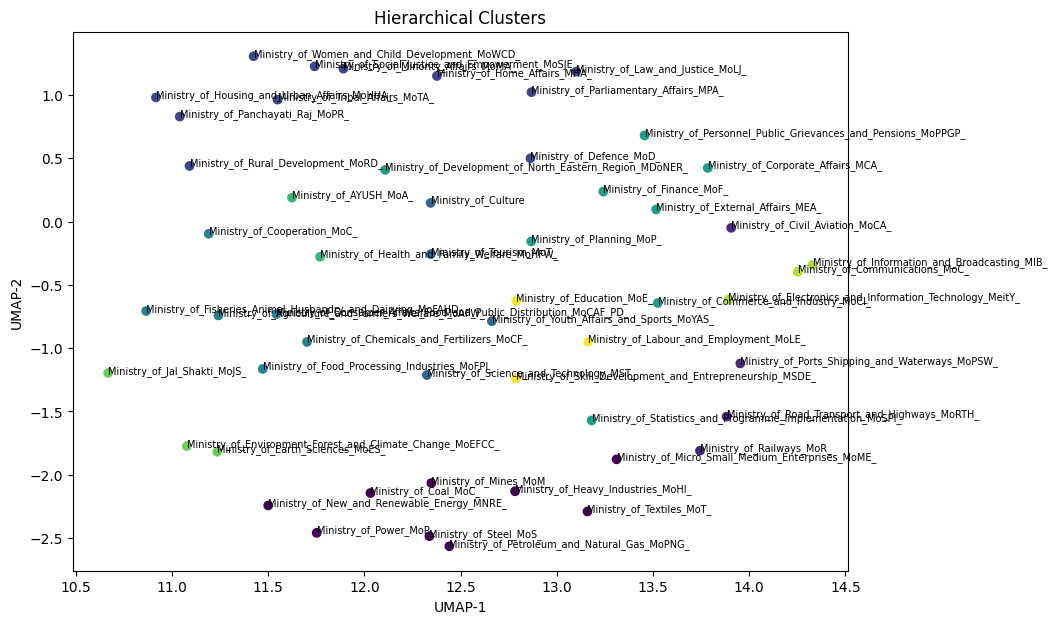

/home/devadatta/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


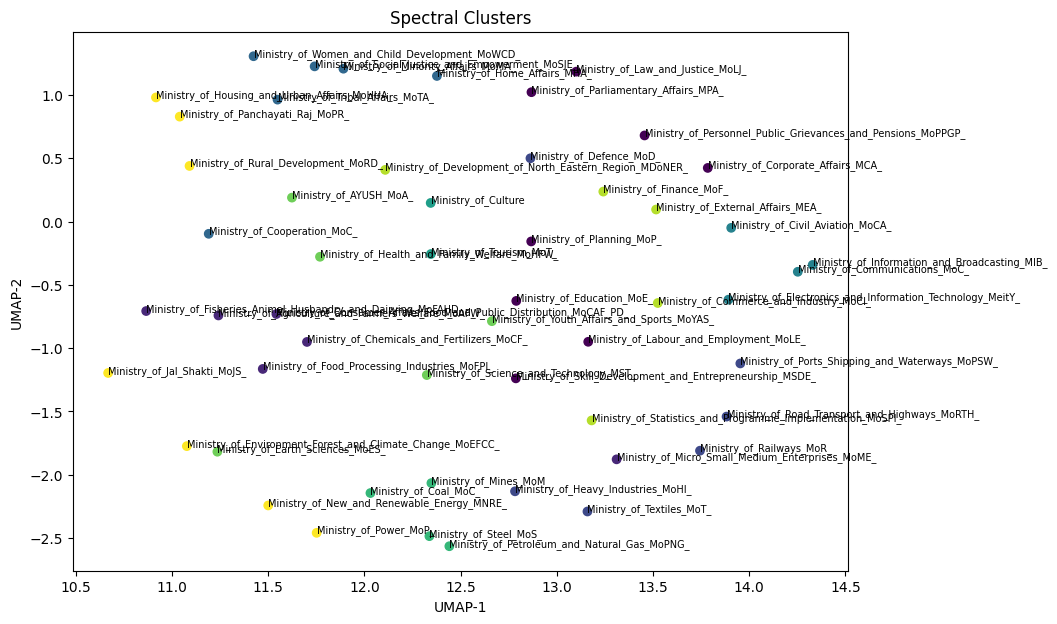

/home/devadatta/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


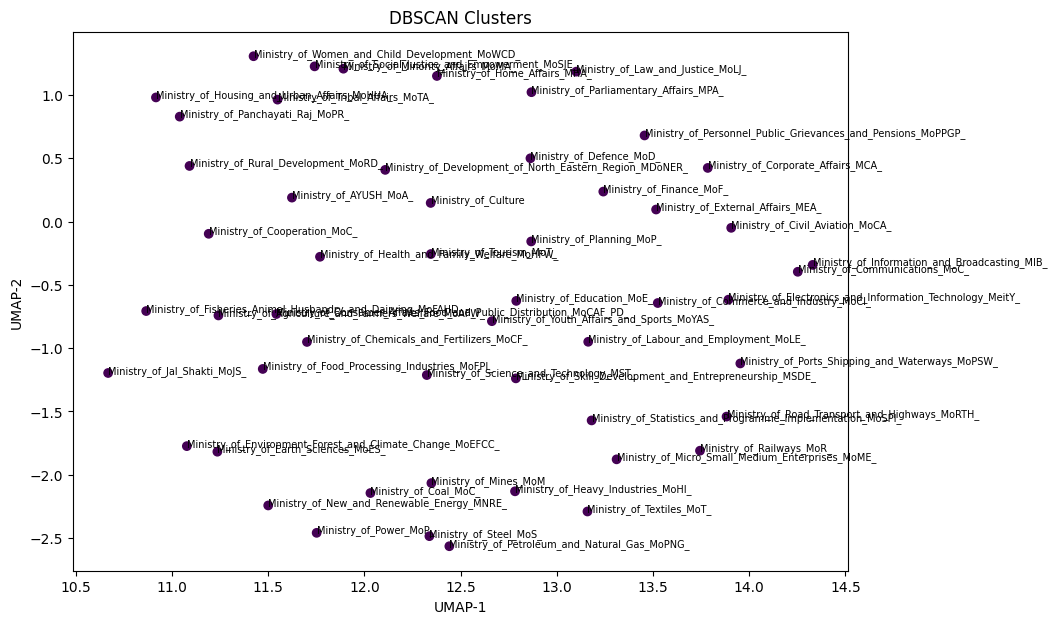

/home/devadatta/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


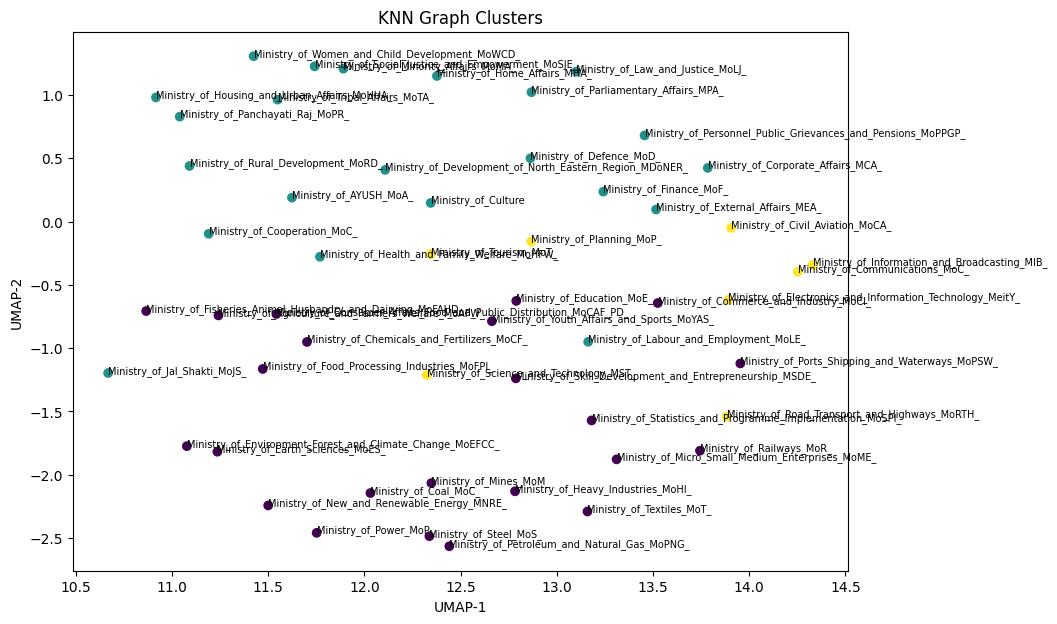

In [23]:
visualize_clusters(X, labels_kmeans, names, "KMeans Clusters")
visualize_clusters(X, labels_gmm, names, "GMM Clusters")
visualize_clusters(X, labels_hier, names, "Hierarchical Clusters")
visualize_clusters(X, labels_spectral, names, "Spectral Clusters")
visualize_clusters(X, labels_dbscan, names, "DBSCAN Clusters")
visualize_clusters(X, labels_knn, names, "KNN Graph Clusters")

In [24]:
def compare_all(X, names, all_labels):
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_2d = reducer.fit_transform(X)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, (algo, labels) in enumerate(all_labels.items()):
        ax = axes[i]
        ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels)
        ax.set_title(algo)

    plt.tight_layout()
    plt.show()

/home/devadatta/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


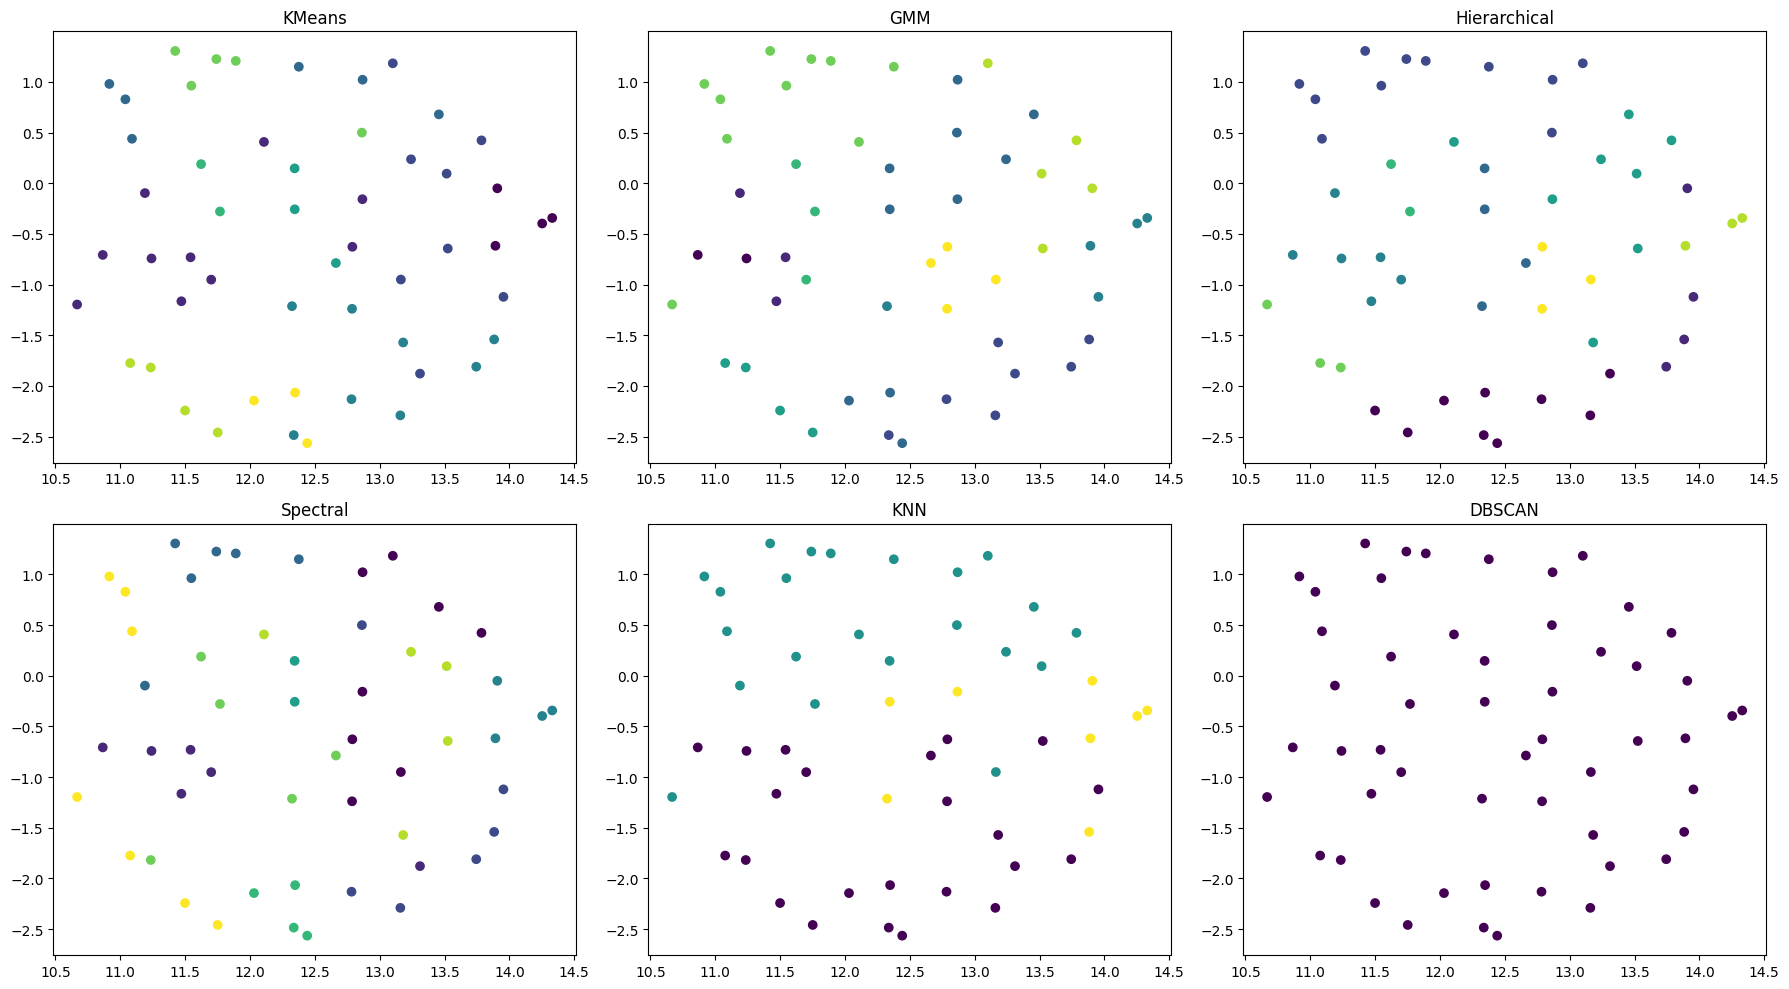

In [25]:
all_labels = {
    "KMeans": labels_kmeans,
    "GMM": labels_gmm,
    "Hierarchical": labels_hier,
    "Spectral": labels_spectral,
    "KNN": labels_knn,
    "DBSCAN": labels_dbscan,
}

compare_all(X, names, all_labels)

/home/devadatta/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


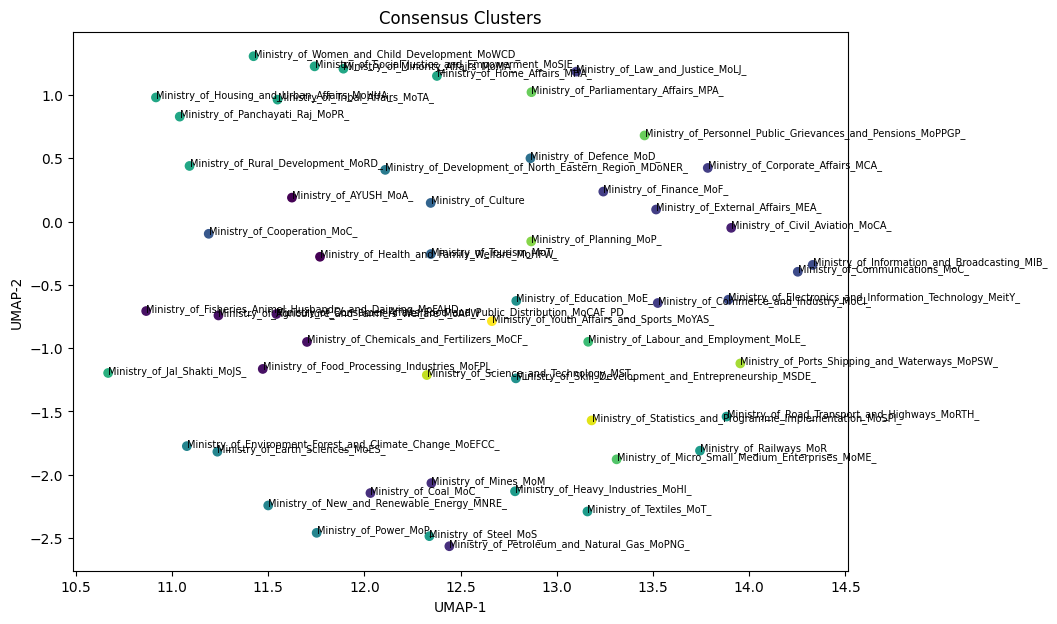

In [26]:
consensus_labels = np.zeros(n)

for cluster_id, comp in enumerate(components):
    for ministry in comp:
        idx = names.index(ministry)
        consensus_labels[idx] = cluster_id

visualize_clusters(X, consensus_labels, names, "Consensus Clusters")